# 原始数据处理

In [2]:
import pandas as pd
import glob
import os

from fontTools.misc.cython import returns

# 你的Excel文件夹
folder = r'U:\YuanqiHua\High speed\Final analysis\test'

# 找到所有xlsx文件
files = [f for f in glob.glob(folder + r'\*.csv') if 'combined' not in f]

all_df = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # ⭐ 添加 Filename 列（只保留文件名，不含路径）
    filename = os.path.basename(file)
    df["Filename"] = filename

    all_df.append(df)

# 纵向拼接（append）
final_df = pd.concat(all_df, ignore_index=True)

# 保存
final_df.to_csv(folder + r'\combined.csv', index=False)

print("All files combined.")


Processing: U:\YuanqiHua\High speed\Final analysis\test\260114  wt1 MTZ control_1000fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260122 wt1 MTZ_1000fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260123 wt1 MTZ_1000fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260127 dmrt3 MTZ_1000fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260128 dmrt3 MTZ(1000hz)_1000fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260128 dmrt3 MTZ(800hz)_800fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260129 wt1 MTZ(800hz)_800fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260204 wt1 MTZ(750hz)_750fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260205 wt1 MTZ_750fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260212 MTZ control_750fps.csv
Processing: U:\YuanqiHua\High speed\Final analysis\test\260213 MTZ control_750fps.csv
Processing: U:\YuanqiHua\High speed\Final

In [3]:
infile = r"U:\YuanqiHua\High speed\Final analysis\test\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df = pd.read_csv(infile)

# 判断左右

In [6]:
df.head()

NameError: name 'df' is not defined

# 读取

In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
import  tempfile
import matplotlib.colors as mcolors
import pandas as pd
import glob
import os

In [2]:
# =========================
# 1) 读入数据
# =========================
folder = r'U:\YuanqiHua\High speed\Final analysis\test'

infile = r"U:\YuanqiHua\High speed\Final analysis\test\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df = pd.read_csv(infile)


In [110]:
infile2 = r"U:\YuanqiHua\High speed\Final analysis\First10hb\combined.csv"   # 你本地就换成 r"U:\...\combined.csv"
df2 = pd.read_csv(infile2)

In [5]:
# =========================
# 2) 生成 Stimulus / Group
#    规则：
#    - 有 HS => Head stimulus，否则 Tail stimulus
#    - 含 control 或 ctrl => Control
#    - 否则：含 wt1 => wt1_MTZ；含 d3 => d3_MTZ
# =========================

# 统一小写方便判断
geno = df["Genotype"].astype(str).str.lower()

# Stimulus
df["Stimulus"] = geno.fillna("").str.lower().apply(lambda x:
                                                    "Head" if "hs" in x
                                                    else "OMR" if ("omr" in x or "fs" in x)
                                                    else "Tail"
                                                   )

# Group
def get_group(x):
    if "control" in x or "ctrl" in x:
        return "Control"
    elif "wt1" in x:
        return "wt1_MTZ"
    elif "d3" in x:
        return "d3_MTZ"

df["Group"] = geno.apply(get_group)
print(df["Stimulus"])

0      Tail
1      Tail
2      Tail
3      Tail
4      Tail
       ... 
908     OMR
909     OMR
910     OMR
911     OMR
912     OMR
Name: Stimulus, Length: 913, dtype: object


In [6]:
# unique ID
df["fish_key"] = df["Filename"].astype(str) + "_" + df["Larva ID"].astype(str)
df["UniqueID"] = df.groupby("Group")["fish_key"].transform(lambda s: pd.factorize(s)[0] + 1)


In [7]:
df.to_csv(folder + r'\combined.csv', index=False)


## QC （剔除单侧摆动的情况）

In [5]:
df[df["Nr. half beats"] < 2]

,Larva ID,Genotype,Swim_ID,Peak_sequence,Peak_deflection,Movement duration,Nr. half beats,Freq. half beats,Alternation,Max. deflection,...,Mean curvature during swimming beats,Turning bias to R/L during swimming,Laterality_Index_swimming,Swimming_valid,Fail_reason,Filename,Stimulus,Group,fish_key,UniqueID
41,2,wt1-MTZ,7,R,15.929,0.031,1,32.258,NaN,15.929,...,74.614,inf,1.0,1,NaN,260122 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260122 wt1 MTZ_1000fps.csv_2,2
46,3,wt1-MTZ,4,R,64.144,0.017,1,58.824,NaN,64.144,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260122 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260122 wt1 MTZ_1000fps.csv_3,3
89,3,wt1-MTZ,7,R,41.315,0.073,1,13.699,NaN,41.315,...,81.982,inf,1.0,1,NaN,260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_3,7
96,4,wt1-MTZ,6,R,28.381,0.056,1,17.857,NaN,28.381,...,45.968,inf,1.0,1,NaN,260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_4,8
98,5,wt1-MTZ,2,L,-50.964,0.042,1,23.810,NaN,50.964,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260123 wt1 MTZ_1000fps.csv,Tail,wt1_MTZ,260123 wt1 MTZ_1000fps.csv_5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,1,d3-MTZ-FS,7,L,-8.847,0.029,1,34.483,NaN,8.847,...,106.997,0.0,-1.0,1,NaN,260225 dmrt3 MTZ_750fps.csv,OMR,d3_MTZ,260225 dmrt3 MTZ_750fps.csv_1,19
596,1,d3-MTZ-OMR,0,L,-77.219,0.043,1,23.256,NaN,77.219,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260225 dmrt3 MTZ_750fps.csv,OMR,d3_MTZ,260225 dmrt3 MTZ_750fps.csv_1,19
612,1,MTZ-ctrl-HS,1,R,60.717,0.028,1,35.714,NaN,60.717,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260226 MTZ control_750fps.csv,Head,Control,260226 MTZ control_750fps.csv_1,18
614,1,MTZ-ctrl-HS,3,R,61.959,0.049,1,20.408,NaN,61.959,...,NaN,NaN,NaN,0,No swimming beats after threshold (<50deg),260226 MTZ control_750fps.csv,Head,Control,260226 MTZ control_750fps.csv_1,18


In [6]:
summary = (
    df
    .assign(HB_less2 = df["Nr. half beats"] < 2)
    .groupby("Group")
    .agg(
        total_counts = ("Nr. half beats", "count"),
        less2_count = ("HB_less2", "sum")
    )
)

print(summary)

# df["Nr. half beats"] < 2 得到布尔序列
# .assign(HB_less2 = df["Nr. half beats"] < 2) 原来的 df上新增一列 HB_less2

         total_counts  less2_count
Group                             
Control           322           16
d3_MTZ            355           16
wt1_MTZ           236           34


In [21]:
print(df.loc[df["Nr. half beats"] < 2,
       ["Filename","Larva ID","Swim_ID","Stimulus","Nr. half beats","Alternation","Group"]].sort_values(by="Filename")
      )

# df.loc[行条件, 列选择] 选出 Nr. half beats 小于 2 的所有行，只保留后面列出来的这几列。

                           Filename  Larva ID  Swim_ID Stimulus  \
19   260114 MTZ control_1000fps.csv         2        2     Tail   
50       260122 wt1 MTZ_1000fps.csv         3        4     Tail   
202     260128 dmrt3 MTZ_800fps.csv         3        3     Tail   
203     260128 dmrt3 MTZ_800fps.csv         3        4     Tail   
289       260204 wt1 MTZ_750fps.csv         2        3     Tail   
312       260204 wt1 MTZ_750fps.csv         2       11     Head   
313       260204 wt1 MTZ_750fps.csv         2       12     Head   
322       260204 wt1 MTZ_750fps.csv         2        9     Head   
373       260205 wt1 MTZ_750fps.csv         4        3     Head   
370       260205 wt1 MTZ_750fps.csv         4        0     Head   
342       260205 wt1 MTZ_750fps.csv         4        5     Tail   
357       260205 wt1 MTZ_750fps.csv         1        5     Head   
455   260212 MTZ control_750fps.csv         3        2     Head   
456   260212 MTZ control_750fps.csv         3        3     Hea

In [7]:
# 剔除单侧摆动的情况
df_original = df.copy()
df = df[df["Nr. half beats"] >= 2].copy()

### First10Hb 清洗

In [136]:
counts = (
    df.groupby(['Group','UniqueID','Swim_ID'])
      .size()
      .reset_index(name='count')
)

counts[counts['count'] <= 2]

,Group,UniqueID,Swim_ID,count
2,Control,1,2,2
46,Control,5,7,1
75,Control,8,0,2
77,Control,8,2,2
79,Control,8,4,2
...,...,...,...,...
567,wt1_MTZ,22,3,2
568,wt1_MTZ,22,4,2
571,wt1_MTZ,23,2,1
573,wt1_MTZ,24,0,2


In [140]:
mask = df.groupby(['Group','UniqueID','Swim_ID'])['Swim_ID'].transform('size') <= 2
df_small = df[mask]
print(df_small)

      Larva ID         Genotype  Swim_ID  HB_index  Interval_s  Inst_freq_Hz  \
94           1  wt1-MTZ-control        2         1    0.086000     11.627907   
95           1  wt1-MTZ-control        2         2    0.069000     14.492754   
303          1          wt1-MTZ        1         1    0.033000     30.303030   
304          2          wt1-MTZ        0         1    0.056000     17.857143   
313          3          wt1-MTZ        2         1    0.042000     23.809524   
...        ...              ...      ...       ...         ...           ...   
2653         4     MTZ-ctrl-OMR       15         2    0.026667     37.500000   
2729         4     MTZ-ctrl-OMR        7         1    0.026667     37.500000   
2730         4     MTZ-ctrl-OMR        7         2    0.028000     35.714286   
2735         4     MTZ-ctrl-OMR        9         1    0.025333     39.473684   
2736         4     MTZ-ctrl-OMR        9         2    0.026667     37.500000   

                                       

In [141]:
mask = df.groupby(['Group','UniqueID','Swim_ID'])['Swim_ID'].transform('size') > 2
df_filter = df[mask]

In [142]:
df_filter.groupby(['Group','UniqueID','Swim_ID']).size().min()


np.int64(3)

In [143]:
df_filter.to_csv(folder + r'\combined_10Hb_filter.csv', index=False)

## 简单查看

In [8]:
df.groupby(['Stimulus','Group'])['HB10s_alt'].agg(['min', 'max'])


min  max
Stimulus Group                 
Head     Control  0.333333  1.0
         d3_MTZ   0.000000  1.0
         wt1_MTZ  0.500000  1.0
OMR      Control  0.777778  1.0
         d3_MTZ   0.750000  1.0
         wt1_MTZ  0.888889  1.0
Tail     Control  0.000000  1.0
         d3_MTZ   0.500000  1.0
         wt1_MTZ  0.000000  1.0

In [23]:
df.groupby(["Stimulus","Group" ])[["Nr. half beats","Freq. half beats",'Max. deflection','Longest tail trajectory among half beats','Cumulative tail trajectory','Max. curvature','Movement duration','Swimming duration','Turning bias to R/L']].mean()


Nr. half beats  Freq. half beats  Max. deflection  \
Stimulus Group                                                        
Head     Control       11.000000         43.947406        76.084101   
         d3_MTZ         6.732558         31.516640        37.668547   
         wt1_MTZ        6.114286         30.308143        68.613143   
Tail     Control       10.427350         40.972828        66.376274   
         d3_MTZ         7.494505         32.367648        50.448484   
         wt1_MTZ        9.265823         32.645051        58.839367   

                  Longest tail trajectory among half beats  \
Stimulus Group                                               
Head     Control                                424.883377   
         d3_MTZ                                 396.692535   
         wt1_MTZ                                448.066629   
Tail     Control                                633.267948   
         d3_MTZ                                 535.467714   
         wt1_MTZ                                432.960494   

                  Cumulative tail trajectory  Max. curvature  \
Stimulus Group                                                 
Head     Control                 2611.204188      196.947855   
         d3_MTZ                  1344.445209      141.388849   
         wt1_MTZ                 1023.023400      238.171829   
Tail     Control                 4016.901915      187.335479   
         d3_MTZ                  1821.965319      149.823110   
         wt1_MTZ                 1668.716032      210.407152   

                  Movement duration  Swimming duration  Turning bias to R/L  
Stimulus Group                                                               
Head     Control           0.240246           0.254492                  inf  
         d3_MTZ            0.225744           0.218023                  inf  
         wt1_MTZ           0.265514           0.269167                  inf  
Tail     Control           0.257000           0.234060                  inf  
         d3_MTZ            0.226198           0.220885                  inf  
         wt1_MTZ           0.303209           0.293745                  inf

In [24]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('Q("Max. deflection") ~ C(Group) * C(Stimulus)', data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)
print(anova)

# F ：组间差异相对于组内波动的比例,F=组间方差/组内方差。 如果：组之间差异很大, 组内数据很稳定, 那么 F 会很大。
# PR(>F) ：p 值（显著性概率）
# F 大 + p 小 → 真差异
# F 大 + p 大 → 样本不足
# F 小 + p 小 → 样本巨大

# C(Group): 如果把 Head 和 Tail 混在一起看，Control、wt1_MTZ、d3_MTZ 整体水平比较。
# C(Stimulus) : Head vs Tail 在“所有组混在一起”时，平均水平是否不同。
# C(Group):C(Stimulus) ： 不同组对 Head 和 Tail 的反应方式比较。

ModuleNotFoundError: No module named 'statsmodels'

In [9]:
df.groupby(['Group','Stimulus'])['UniqueID'].nunique() # “number of unique values”（唯一值的数量）


Group    Stimulus
Control  Head        11
         OMR          9
         Tail        12
d3_MTZ   Head         7
         OMR         15
         Tail        10
wt1_MTZ  Head         7
         OMR          7
         Tail        23
Name: UniqueID, dtype: int64

# 清洗数据

## Functions

In [10]:
# 清洗

def rm_outliers(s):
    s = s.dropna()
    if len(s) < 4:
        return s
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s[(s >= lo) & (s <= hi)]

def make_clean_dfs(df, ycol):
    groups = ["Control", "wt1_MTZ", "d3_MTZ"]
    out_swim = []

    for stim in ["Head", "Tail", "OMR"]:
        data_swim = df[df["Stimulus"] == stim]

         # ——A) swim 层：按 (Stimulus, Group) 分别 IQR，删“行”
        for g in groups:
            tmp = data_swim[data_swim["Group"] == g].copy() # e.g. ， tmp 就是Head/control组的表格

            kept_vals = rm_outliers(tmp[ycol])      # 返回被保留的 Series（带 index）
            tmp = tmp.loc[kept_vals.index]          # ✅ 按标签（index）选行。用 index 保留整行

            out_swim.append(tmp) # 最后，out_swim = [Head-Control 的 tmp, Head-wt1 的 tmp, Head-d3 的 tmp,。。。] 注意：这还是 list，不是表格。

    df_swim_clean  = pd.concat(out_swim, ignore_index=True) # 把那 6 个小表“上下拼起来”，变成一个大的 新的 DataFrame。

    # ——B) fish 层：用 clean swim 计算每鱼均值
    df_fish_clean0 = (
        df_swim_clean.groupby(["UniqueID","Group","Stimulus"])[ycol]
        .mean()
        .reset_index()
    )

    # ——C) fish 层再 IQR：按 (Stimulus, Group) 删“鱼”
    out_fish = []
    for stim in ["Head", "Tail", "OMR"]:
        tmp_stim = df_fish_clean0[df_fish_clean0["Stimulus"] == stim]
        for g in groups:
            tmp = tmp_stim[tmp_stim["Group"] == g].copy()
            kept = rm_outliers(tmp[ycol])
            tmp = tmp.loc[kept.index]
            out_fish.append(tmp)

    df_fish_clean = pd.concat(out_fish, ignore_index=True)

    return df_swim_clean, df_fish_clean0, df_fish_clean

In [12]:
# 测试清洗
ycol = "Freq. half beats"

df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

In [13]:
print("原始 swim 行数:", len(df))
print("清洗后 swim 行数:", len(df_swim_clean))

print("fish 均值行数（清洗后 swim 计算）:", len(df_fish_clean0))
print("fish 再清洗后行数:", len(df_fish_clean))

原始 swim 行数: 847
清洗后 swim 行数: 834
fish 均值行数（清洗后 swim 计算）: 101
fish 再清洗后行数: 97


In [15]:
check = (
    df.groupby(["Stimulus","Group"])[ycol].count().rename("raw_swim")
    .to_frame()
    .join(df_swim_clean.groupby(["Stimulus","Group"])[ycol].count().rename("clean_swim"))
    .join(df_fish_clean0.groupby(["Stimulus","Group"])[ycol].count().rename("fish_before_IQR"))
    .join(df_fish_clean.groupby(["Stimulus","Group"])[ycol].count().rename("fish_after_IQR"))
)
print(check)

                  raw_swim  clean_swim  fish_before_IQR  fish_after_IQR
Stimulus Group                                                         
Head     Control        82          80               11              11
         d3_MTZ         87          84                7               7
         wt1_MTZ        28          27                7               6
OMR      Control       114         114                9               9
         d3_MTZ        172         171               15              14
         wt1_MTZ        25          23                7               7
Tail     Control       110         110               12              10
         d3_MTZ         80          79               10              10
         wt1_MTZ       149         146               23              23


In [14]:
# 作图
from scipy.stats import f_oneway, ttest_ind
import matplotlib.colors as mcolors

def holm_correction(pvals):
    pvals = np.array(pvals)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m)

    for i, idx in enumerate(order):
        adjusted[idx] = min((m - i) * pvals[idx], 1.0)

    # 保证单调性
    adjusted_sorted = adjusted[order]
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
    adjusted[order] = adjusted_sorted

    return adjusted

def darken(color, amount=0.3):
    """
    amount < 1 → 变深
    """
    c = mcolors.to_rgb(color)
    return tuple([x * amount for x in c])

def star(p):
    if p < 0.0001: return "****"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def add_sig(ax, x1, x2, y, text):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1,color="black")
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom")


In [15]:
# 作图
def plot(folder,ycol,Ylabel,df_swim_clean, df_fish_clean):

    os.makedirs(folder, exist_ok=True)  # ⭐ 自动创建文件夹


    groups = ["Control","wt1_MTZ","d3_MTZ"]
    pvalue_table = []
    values = []

    for stim in ["Head","Tail", "OMR"]:

        vals = []
        n_fish = []
        n_swim = []

        df_fish = df_fish_clean

        for g in groups:

            fish_vals = df_fish[(df_fish["Stimulus"]==stim) & (df_fish["Group"]==g)][ycol]
            swim_vals = df_swim_clean[(df_swim_clean["Stimulus"]==stim) & (df_swim_clean["Group"]==g)][ycol]



            vals.append(fish_vals)
            n_fish.append(len(fish_vals))
            n_swim.append(len(swim_vals))


        plt.figure(figsize=(6,4))
        ax = plt.gca()

        # ✅ 标签：n=鱼数(泳次)
        labels = [f"{g}\n(n={nf} ({ns}))" for g, nf, ns in zip(groups, n_fish, n_swim)]

    # 画箱线图：不显示 outlier 点
        colors = ["#E5E5E5", "#E18E96", "#88D498"]

        bp = ax.boxplot(vals, tick_labels=labels, showfliers=False,patch_artist=True)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        # 计算每组 mean
        means = [v.mean() for v in vals]

        # 在每个箱体上方标 mean
        for i, m in enumerate(means):
            ax.text(i+1, m, f"{m:.2f}",
                    ha='center',
                    va='bottom',
                    fontsize=10,
                    color='black')

        for i, (v, color) in enumerate(zip(vals, colors)):
            x = np.random.normal(i+1, 0.04, size=len(v))
            darker = darken(color, 0.6)   # 0.6 越小越深

            ax.scatter(x, v,
                       color=darker,
                       alpha=0.6,
                       s=35,
                       zorder=3)


        ax.set_ylabel(f"{Ylabel}")
                # 去除外方框（右边和上边）
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # 只保留下边和左边
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.set_xlabel("")
        ax.text(0.5, -0.18, f"{stim} stimulus", transform=ax.transAxes,
            ha="center", va="top", fontsize=12)


        # -------------------
        # 1️⃣ ANOVA
        # -------------------
        if all(len(v) >= 2 for v in vals):
            F_stat, p_anova = f_oneway(*vals)
        else:
            F_stat, p_anova = np.nan, np.nan

        # -------------------
        # 2️⃣ pairwise t-tests
        # -------------------
        pairs = [(0,1), (0,2), (1,2)]
        raw_pvals = []
        pair_info = []

        for i, j in pairs:
            if len(vals[i]) >= 2 and len(vals[j]) >= 2:
                t_stat, p_raw = ttest_ind(vals[i], vals[j], equal_var=False)

                raw_pvals.append(p_raw)
                pair_info.append((i, j, t_stat, p_raw))
            else:
                raw_pvals.append(np.nan)
                pair_info.append((i, j, np.nan, np.nan))

        # -------------------
        # 3️⃣ Holm correction
        # -------------------
        valid_p = [p for p in raw_pvals if not np.isnan(p)]
        adjusted_p = holm_correction(valid_p) if len(valid_p) > 0 else []

        # -------------------
        # 4) 画显著性（用 Holm 后 p）
        # -------------------
        k = 0
        finite_vals = [v for v in vals if len(v)>0 and np.isfinite(v).any()]
        if len(finite_vals) > 0:
            vmax = max([np.nanmax(v) for v in finite_vals])
            vmin = min([np.nanmin(v) for v in finite_vals])
            y0 = vmax * 1.05
            step = (vmax - vmin) * 0.12 if vmax > vmin else 0.1
        else:
            y0, step = 1.0, 0.1

        adj_index = 0

        for idx, (i, j, t_stat, p_raw) in enumerate(pair_info):

            if not np.isnan(p_raw):
                p_holm = adjusted_p[adj_index]
                adj_index += 1
            else:
                p_holm = np.nan

            significant = p_holm < 0.05 if not np.isnan(p_holm) else False

            # ⭐ 存入表格
            pvalue_table.append({
                "Variable": ycol,
                "Stimulus": stim,
                "Test": "ANOVA",
                "F_value": F_stat,
                "p_ANOVA": p_anova,
                "Group1": groups[i],
                "Group2": groups[j],
                "n1": len(vals[i]),
                "n2": len(vals[j]),
                "t_value": t_stat,
                "p_raw": p_raw,
                "p_holm": p_holm,
                "Significant": significant
            })

            # ⭐ 图上只画 Holm 后显著
            if significant:
                add_sig(ax, i+1, j+1, y0 + k*step, star(p_holm))
                k += 1

        plt.tight_layout()

      # # 先临时保存（一定不空白）
      # tmp_path = os.path.join(tempfile.gettempdir(), f"tmp_{stim}.png")
      # plt.savefig(tmp_path, dpi=300, bbox_inches="tight")

      # plt.show()

      # save = input(f"Save {stim} figure? (y/n): ")
      # if save.lower() == "y":
      #     name = input("Enter file name (without extension): ")
      #     final_path = os.path.join(folder, f"{name}.png")
      #     # 把临时文件复制到目标位置
      #     import shutil
      #     shutil.copyfile(tmp_path, final_path)
      #     print("Saved to:", final_path)
      # else:
      #      print("Not saved.")

        plt.tight_layout()

        safe_ycol = ycol.replace("/", "_").replace(" ", "_")
        safe_stim = stim.replace("/", "_").replace(" ", "_")

        final_path = os.path.join(folder, f"{safe_ycol}_{safe_stim}.png")
        plt.savefig(final_path, dpi=300, bbox_inches="tight")

        plt.show()
        print("Saved to:", final_path)

    # 转成 DataFrame
    df_pvalues = pd.DataFrame(pvalue_table)

    print(df_pvalues)

    # 保存为 csv
    #save_path = os.path.join(folder, f"{ycol}_ANOVA_Holm_stats.csv")
    #df_pvalues.to_csv(save_path, index=False)

    #print("P-value table saved to:", save_path)

    return df_pvalues

In [16]:
# 频率分布作图
def Freq_plot1(folder, ycol,savename,df_fish_clean):
    os.makedirs(folder, exist_ok=True)

    groups = ["Control","wt1_MTZ","d3_MTZ"]
    # colors = ["#999999", "#E18E96", "#88D498"]
    ycol = ycol
    colors = ["#7A7A7A", "#C65A5A", "#4E9F6D"]
    colors_edge = {"Control":"#212121", "wt1_MTZ":"#8B0000", "d3_MTZ":"#004D40"}  # 深轮廓


    for stim in ["Head","Tail", "OMR"]:

        plt.figure(figsize=(6,4))

         # ⭐ 1️⃣ 先拿到当前 stimulus 所有数据
        all_vals = df_fish_clean[
            df_fish_clean["Stimulus"] == stim
        ][ycol].dropna()

         # ⭐ 2️⃣ 统一 bins（关键修改）
        bins = np.linspace(all_vals.min(), all_vals.max(), 12)

        for g, color in zip(groups, colors):
            vals = df_fish_clean[
                (df_fish_clean["Stimulus"] == stim) &
                (df_fish_clean["Group"] == g)
            ][ycol]

            plt.hist(vals,
                     bins=bins,
                     density=True,
                     weights=np.ones(len(vals)) / len(vals),
                     alpha=0.3,
                     label=g,
                     color=color,
                     edgecolor=colors_edge[g],
                     linewidth=1.5)

        plt.title(f"{stim} stimulus")
        plt.xlabel(f"Swim Frequency (Hz)")
        plt.ylabel("Probability")
        plt.legend()

            # ⭐ 生成完整文件路径
        filename = f"{savename}_{stim}.png"
        full_path = os.path.join(folder, filename)
        plt.savefig(full_path, dpi=300, bbox_inches="tight")
        plt.show()

    return

In [17]:
# 单个频率分布作图
def Freq_plot2(folder, ycol,savename,df_fish_clean):
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import gaussian_kde

    groups = ["Control","wt1_MTZ","d3_MTZ"]
    ycol = ycol

    for stim in ["Head","Tail", "OMR"]:
        for g in groups:
            vals = df_fish_clean[
                (df_fish_clean["Stimulus"] == stim) &
                (df_fish_clean["Group"] == g)
            ][ycol].dropna().to_numpy()

            plt.figure(figsize=(5,4))
            bins = np.arange(0, 61, 2)   # 每 2 Hz 一个 bin
            plt.hist(vals, bins=bins, density=True, alpha=0.4)
            plt.xlim(0,60)

            if len(vals) >= 3 and vals.min() != vals.max():
                xs = np.linspace(vals.min(), vals.max(), 200)
                kde = gaussian_kde(vals)
                ys = kde(xs)
                plt.plot(xs, ys)

            plt.title(f"{stim} - {g} (n={len(vals)})")
            plt.xticks([0,10,20,30,40,50,60])
            plt.xlabel("Half-beat_frequency (Hz)")
            plt.ylabel("Density")
            plt.tight_layout()

            filename = f"{savename}_{stim}_{g}.png"
            full_path = os.path.join(folder, filename)
            plt.savefig(full_path, dpi=300, bbox_inches="tight")

            plt.show()
    return

## Plot

C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_36336\1533143646.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


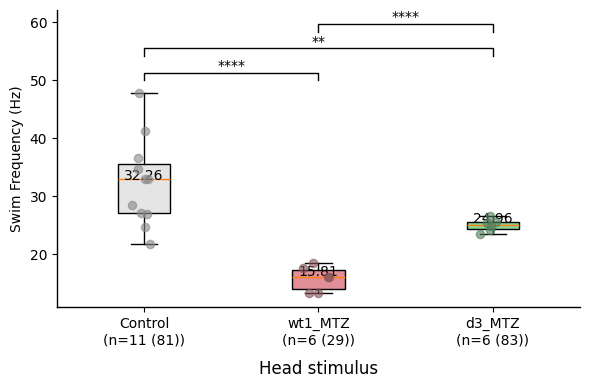

KeyboardInterrupt: Interrupted by user

In [58]:
# Single  Plot
ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

df_plot = plot(folder=r'\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Plot',
               ycol=ycol,
               Ylabel="Swim Frequency (Hz)",
               df_swim_clean=df_swim_clean,
               df_fish_clean=df_fish_clean)

In [1]:
df.groupby(["Stimulus", "Group"])["UniqueID"].nunique()

NameError: name 'df' is not defined

In [203]:
folder = r'U:\YuanqiHua\High speed\Final analysis\test'


Now processing: Freq. half beats

Please enter save folder for Freq. half beats:
Swim-level rows after cleaning: (834, 55)
Fish-level rows after cleaning: (97, 4)

Fish counts (UniqueID) per Stimulus × Group:
Group     Control  d3_MTZ  wt1_MTZ
Stimulus                          
Head           11       7        6
OMR             9      14        7
Tail           10      10       23


C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


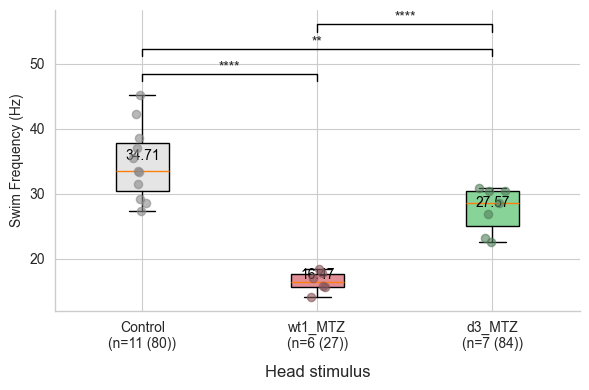

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Freq._half_beats_Head.png


C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


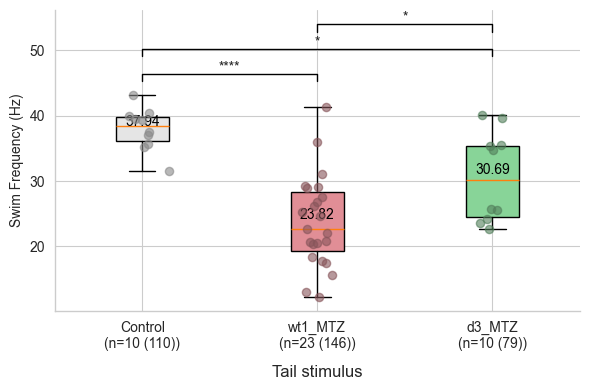

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Freq._half_beats_Tail.png


C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


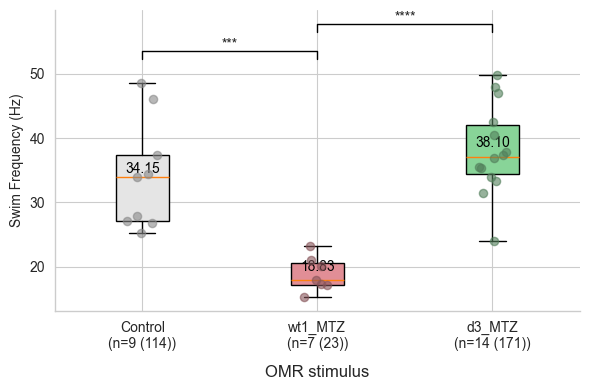

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Freq._half_beats_OMR.png
           Variable Stimulus   Test    F_value       p_ANOVA   Group1  \
0  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  Control   
1  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  Control   
2  Freq. half beats     Head  ANOVA  33.253541  3.103480e-07  wt1_MTZ   
3  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  Control   
4  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  Control   
5  Freq. half beats     Tail  ANOVA  17.733124  3.062983e-06  wt1_MTZ   
6  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  Control   
7  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  Control   
8  Freq. half beats      OMR  ANOVA  18.984605  7.109816e-06  wt1_MTZ   

    Group2  n1  n2   t_value         p_raw        p_holm  Significant  
0  wt1_MTZ  11   6  9.930355  2.620802e-07  7.862406e-07         True  
1   d3_MTZ  11   7  3

C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


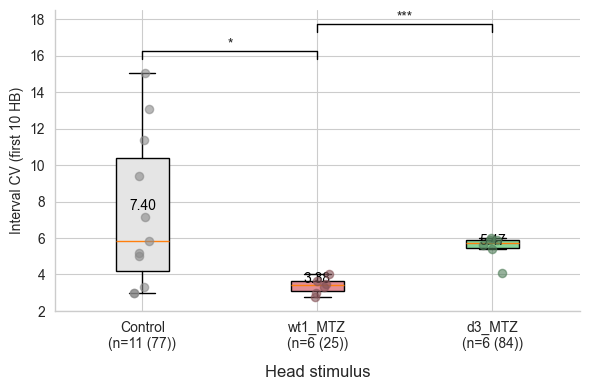

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Nr._half_beats_Head.png


C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


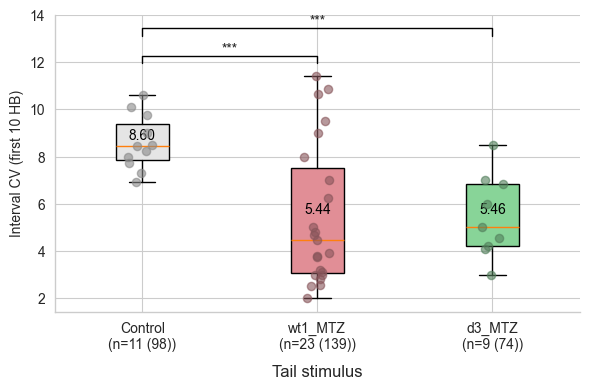

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Nr._half_beats_Tail.png


C:\Users\huayuanqi\AppData\Local\Temp\ipykernel_22464\2358973657.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(vals, labels=labels, showfliers=False,patch_artist=True)


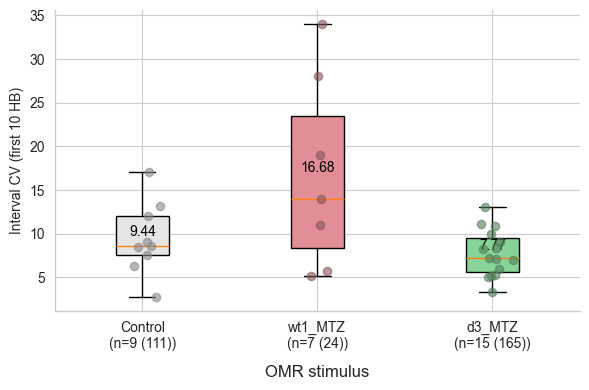

Saved to: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot\1\Nr._half_beats_OMR.png
         Variable Stimulus   Test   F_value   p_ANOVA   Group1   Group2  n1  \
0  Nr. half beats     Head  ANOVA  3.499831  0.049741  Control  wt1_MTZ  11   
1  Nr. half beats     Head  ANOVA  3.499831  0.049741  Control   d3_MTZ  11   
2  Nr. half beats     Head  ANOVA  3.499831  0.049741  wt1_MTZ   d3_MTZ   6   
3  Nr. half beats     Tail  ANOVA  6.858082  0.002749  Control  wt1_MTZ  11   
4  Nr. half beats     Tail  ANOVA  6.858082  0.002749  Control   d3_MTZ  11   
5  Nr. half beats     Tail  ANOVA  6.858082  0.002749  wt1_MTZ   d3_MTZ  23   
6  Nr. half beats      OMR  ANOVA  5.623131  0.008852  Control  wt1_MTZ   9   
7  Nr. half beats      OMR  ANOVA  5.623131  0.008852  Control   d3_MTZ   9   
8  Nr. half beats      OMR  ANOVA  5.623131  0.008852  wt1_MTZ   d3_MTZ   7   

   n2   t_value     p_raw    p_holm  Significant  
0   6  3.119670  0.010383  0.020766         True  
1   6

In [15]:
# multiplot
import tkinter as tk
from tkinter import filedialog

dfs = []
base_folder = r"\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test\Plot"

for ycol, ylabel in [
    ("Freq. half beats", "Swim Frequency (Hz)"),
    ("Nr. half beats", "Interval CV (first 10 HB)"),
]:
    print("\n==============================")
    print("Now processing:", ycol)
    print("==============================")

        # ========= 弹窗选择保存 folder =========
    print(f"\nPlease enter save folder for {ycol}:")
    folder_name = input("Folder name: ").strip()

    save_folder = os.path.join(base_folder, folder_name)

    os.makedirs(save_folder, exist_ok=True)

    # Clean data
    df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)
    print("Swim-level rows after cleaning:", df_swim_clean.shape)
    print("Fish-level rows after cleaning:", df_fish_clean.shape)

    print("\nFish counts (UniqueID) per Stimulus × Group:")
    print(
        df_fish_clean
        .groupby(["Stimulus","Group"])["UniqueID"]
        .nunique()
        .unstack(fill_value=0)
    )

    # Plot
    df_plot = plot(
        folder=save_folder,
        ycol=ycol,
        Ylabel=ylabel,
        df_swim_clean=df_swim_clean,
        df_fish_clean=df_fish_clean
    )

    dfs.append(df_plot)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(os.path.join(base_folder, "ALL_ANOVA_Holm_stats.csv"), index=False)

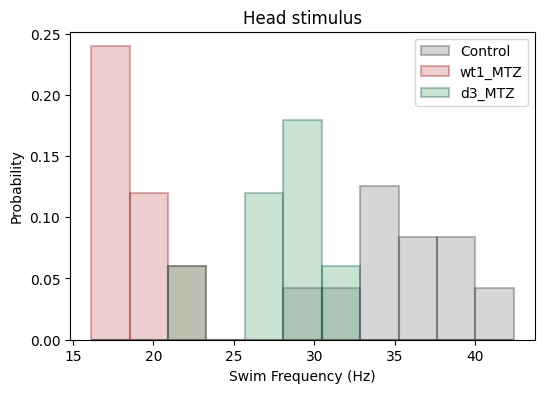

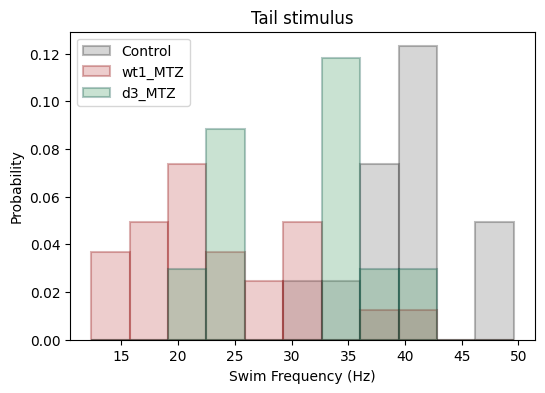

C:\Users\huayuanqi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


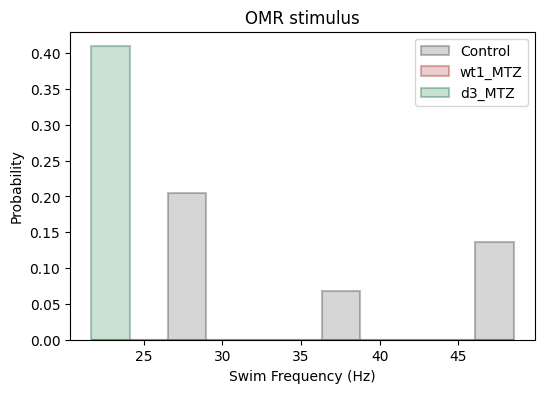

In [206]:
ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

Freq_plot1(
    folder=r"\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\test",
    ycol="Freq. half beats",
    savename = "Freq_distribution",
    df_fish_clean=df_fish_clean
)

# 柱子的位置反映数据分布在哪个频率区间；
# 柱子的高度（在统一 bins 下）反映该组在该区间的相对概率，峰越高通常表示该分布越集中。

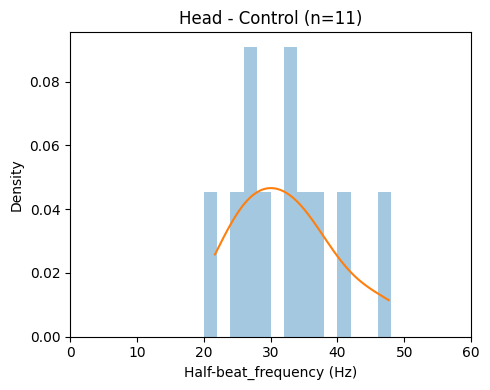

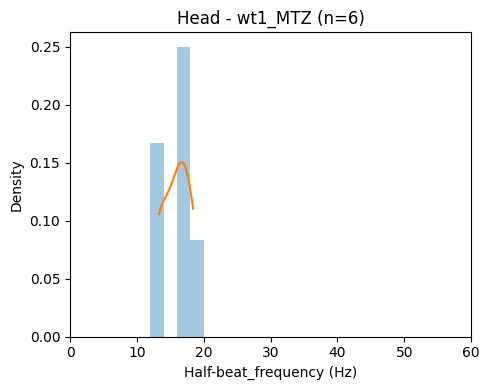

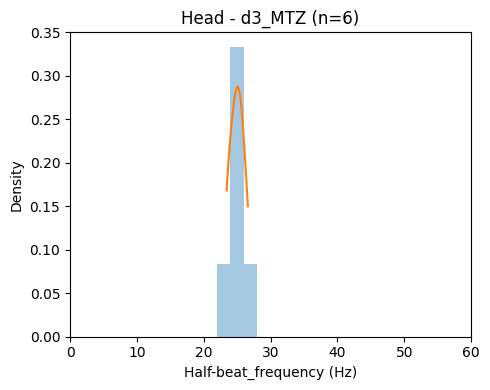

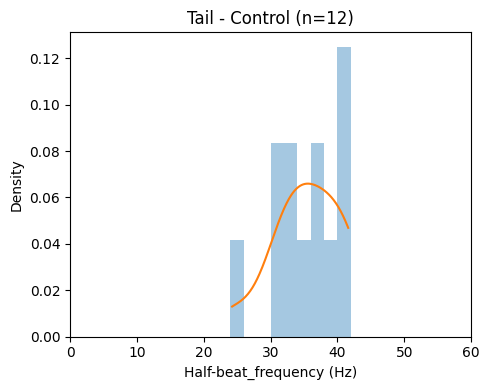

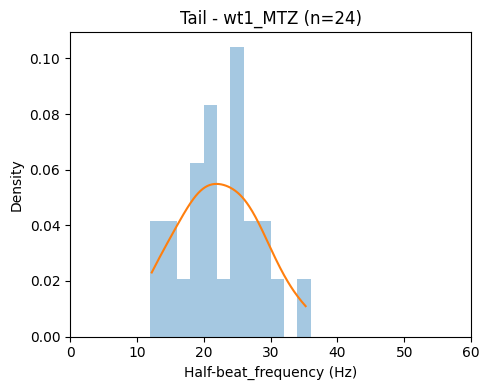

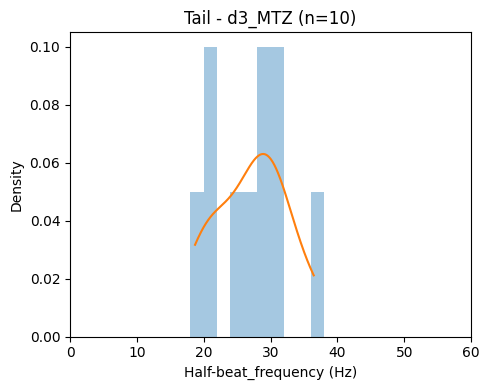

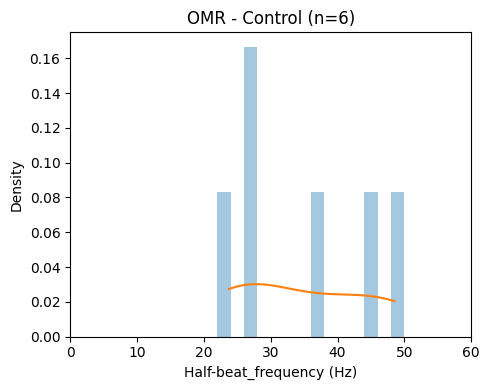

C:\Users\huayuanqi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


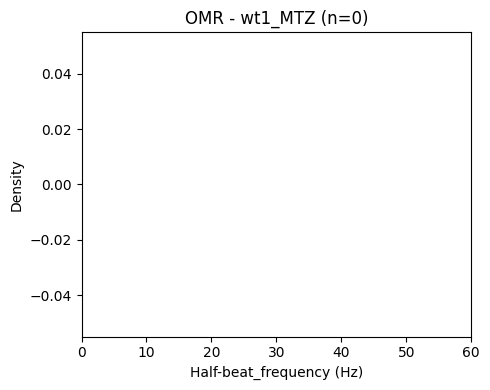

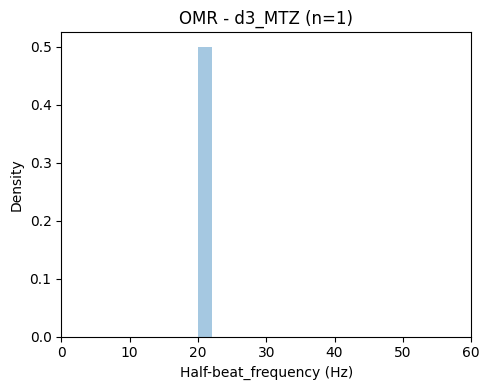

In [71]:
ycol = "Freq. half beats"
df_swim_clean, df_fish_clean0, df_fish_clean = make_clean_dfs(df, ycol)

Freq_plot2(folder=r"\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Plot",
           ycol="Freq. half beats",
           savename = "Freq_distribution",
           df_fish_clean=df_fish_clean
           )

# 前10HB 的细节

In [148]:
ids = (
    df.loc[
        (df["Group"] == "d3_MTZ") &
        (df["Stimulus"] == "Head"),
        "UniqueID"
    ]
    .unique()
)

ids

array([11, 12, 13, 14, 15, 16, 17])

In [149]:
# 清空Nah值并合并
def make_clean_long(df, ycol):
    # groups = ["Control","wt1_MTZ","d3_MTZ"]
    # df = df[df["Group"].isin(groups)].copy() # only for groups over these 3

    df = df.dropna(subset=[ycol])

    df_fish = (
        df.groupby(["Group", "UniqueID" , "Stimulus", "HB_index"], as_index=False)
          .agg({ycol: "mean"})
    )

    return df_fish

In [150]:
df_fish_clean = make_clean_long(df, "Inst_freq_Hz")
df_fish_clean.head(10)

,Group,UniqueID,Stimulus,HB_index,Inst_freq_Hz
0,Control,1,Tail,1,44.328152
1,Control,1,Tail,2,54.162274
2,Control,1,Tail,3,53.550517
3,Control,1,Tail,4,53.773788
4,Control,1,Tail,5,49.710927
5,Control,1,Tail,6,52.780067
6,Control,1,Tail,7,49.454034
7,Control,1,Tail,8,49.152302
8,Control,1,Tail,9,46.458518
9,Control,2,Tail,1,52.631579


In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
from matplotlib.lines import Line2D

colors = {"Control": "#999999", "wt1_MTZ": "#E18E96", "d3_MTZ": "#88D498"}
groups = ["Control", "wt1_MTZ", "d3_MTZ"]
# pairs = [("Control", "wt1_MTZ"), ("Control", "d3_MTZ"), ("wt1_MTZ", "d3_MTZ")] only for ANOVA

def star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def holm_adjust(pvals):
    """
    Holm-Bonferroni adjustment.
    input: list of p-values
    output: list of adjusted p-values in original order
    """
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    for k, idx in enumerate(order):
        adj[idx] = min((m - k) * pvals[idx], 1.0)
    # enforce monotonicity (optional but nice)
    # sort adj by p order and cummax then map back
    adj_sorted = adj[order]
    adj_sorted = np.maximum.accumulate(adj_sorted)
    adj[order] = adj_sorted
    return adj.tolist()

def plot_instfreq_anova_pairs(df_fish_clean, Ylabel, stim="Head", y="Inst_freq_Hz", err="sem"):

    sub = df_fish_clean[df_fish_clean["Stimulus"] == stim].copy() # 只保留 Stimulus == "Head"
    sub = sub.dropna(subset=[y, "HB_index", "Group"]) # 丢掉 y 或 HB_index 或 Group 缺失的行

    hbs = sorted(sub["HB_index"].unique())
    # 如果你的 HB_index 是 1..9，这里会自动是 1..9；否则按实际来
    y_min = float(sub[y].min())
    y_max = float(sub[y].max())
    y_range = max(y_max - y_min, 1e-6)

    fig, ax = plt.subplots(figsize=(8.5, 4.2))

    # 灰白交替背景
    for i, hb in enumerate(hbs, start=1):
        if i % 2 == 0:
            ax.axvspan(hb - 0.5, hb + 0.5, color="0.92", zorder=0)

    offsets = {"Control": -0.22, "wt1_MTZ": 0.0, "d3_MTZ": 0.22}

    # 画点 + mean±SEM/SD
    for g in groups:
        dg = sub[sub["Group"] == g]
        if dg.empty:
            continue

        for hb in hbs:
            vals = dg[dg["HB_index"] == hb][y].to_numpy()
            if len(vals) == 0:
                continue

            x0 = hb + offsets[g]

            # scatter (每条鱼一个点)
            jitter = np.random.uniform(-0.03, 0.03, size=len(vals))
            ax.scatter(np.full(len(vals), x0) + jitter, vals,
                       s=26, alpha=0.65, color=colors[g], edgecolor="none", zorder=2)

            # mean + errorbar
            m = float(np.mean(vals))
            if err == "sd":
                e = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            else:  # sem
                e = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

            ax.errorbar([x0], [m], yerr=[e],
                        fmt="o", markersize=6,
                        color=colors[g], capsize=3, linewidth=1.6, zorder=3)

 # =========================
    # ✅ 统计：只做两组比较（Control vs wt1, Control vs d3）
    # ✅ Holm 校正在“所有HB的两类比较”上一起做
    # =========================
    control_pairs = [("Control", "wt1_MTZ"), ("Control", "d3_MTZ")]

    raw_rows = []
    raw_pvals = []

    for hb in hbs:
        for (g1, g2) in control_pairs:
            v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
            v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()

            # 样本量不够就不检验
            if len(v1) < 2 or len(v2) < 2:
                p = np.nan
            else:
                p = ttest_ind(v1, v2, equal_var=False).pvalue  # Welch t-test ,→ 不要求两组方差相等，更适合你说的“Control 分布很宽”。

            raw_rows.append({"HB_index": hb, "g1": g1, "g2": g2, "n1": len(v1), "n2": len(v2), "p": p})
            raw_pvals.append(p)

    # Holm 校正：对所有有效p一起校正
    stats_table = pd.DataFrame(raw_rows)
    stats_table["p_holm"] = np.nan

    valid_mask = stats_table["p"].notna()
    valid_p = stats_table.loc[valid_mask, "p"].to_list()
    if len(valid_p) > 0:
        adj = holm_adjust(valid_p)
        stats_table.loc[valid_mask, "p_holm"] = adj

    stats_table["star"] = stats_table["p_holm"].apply(lambda x: star(x) if pd.notna(x) else "na")

    # 标星位置：两行（因为只有两种比较）
    for hb in hbs:
        base = float(sub[sub["HB_index"] == hb][y].max())
        step = 0.06 * y_range

        tab_hb = stats_table[stats_table["HB_index"] == hb]

        for k, (g1, g2) in enumerate(control_pairs):
            row = tab_hb[(tab_hb["g1"] == g1) & (tab_hb["g2"] == g2)]
            if row.empty:
                continue
            s = row["star"].iloc[0]
            if s in ["ns", "na"]:
                continue

            # k=0 放第一行，k=1 放第二行
            ax.text(hb, base + (k + 1) * step, s,
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="black")


 #  # 每个HB：ANOVA + 两两比较（Holm校正）
 #  for hb in hbs:
 #      vals_by_group = []
 #      for g in groups:
 #          v = sub[(sub["Group"] == g) & (sub["HB_index"] == hb)][y].to_numpy()
 #          vals_by_group.append(v)

 #      # ANOVA 要求每组至少2个样本比较稳（也可放宽到>=1但意义弱）
 #      if any(len(v) < 2 for v in vals_by_group):
 #          continue

 #      # one-way ANOVA
 #      p_anova = f_oneway(*vals_by_group).pvalue

 #      # 只有 ANOVA 显著才做 posthoc（你也可以改成永远做）
 #      if p_anova >= 0.05:
 #          continue

 #      # pairwise Welch t-tests
 #      pvals = []
 #      for (g1, g2) in pairs:
 #          v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
 #          v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()
 #          p = ttest_ind(v1, v2, equal_var=False).pvalue
 #          pvals.append(p)

 #      pvals_adj = holm_adjust(pvals)

 #      # 星号位置：堆叠三行
 #      base = float(sub[sub["HB_index"] == hb][y].max())
 #      step = 0.06 * y_range

 #      for k, ((g1, g2), p_adj) in enumerate(zip(pairs, pvals_adj)):
 #          s = star(p_adj)
 #          if s == "ns":
 #              continue
 #          ax.text(hb, base + (k + 1) * step, s, ha="center", va="bottom",
 #                  fontsize=11, fontweight="bold", color="black")

    # 标题坐标轴
    ax.set_title(f"{stim} stimulus")
    ax.set_xlabel("HB index")
    Ylabel = Ylabel
    ax.set_ylabel(f"{Ylabel}")
    ax.set_xticks(hbs)

    # ✅ 手动 legend（永远有）
    handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[g],
               markeredgecolor='none', markersize=7, label=g)
        for g in groups
    ]
    ax.legend(handles=handles,
              frameon=False,
              loc="center left",
              bbox_to_anchor=(1.02, 0.5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    filename = f"Frequency for each hb(10hb){stim}.png"
    full_path = os.path.join(folder, filename)
    plt.savefig(full_path, dpi=300, bbox_inches="tight")

    plt.show()

    # ✅ 返回统计表（你要单独查看数值）
    return stats_table



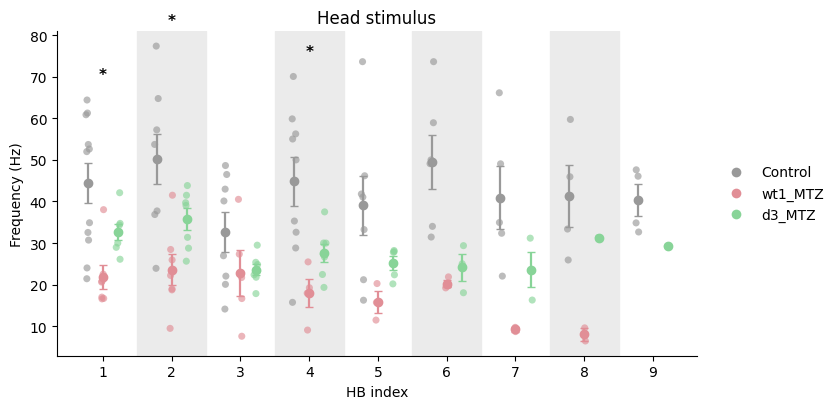

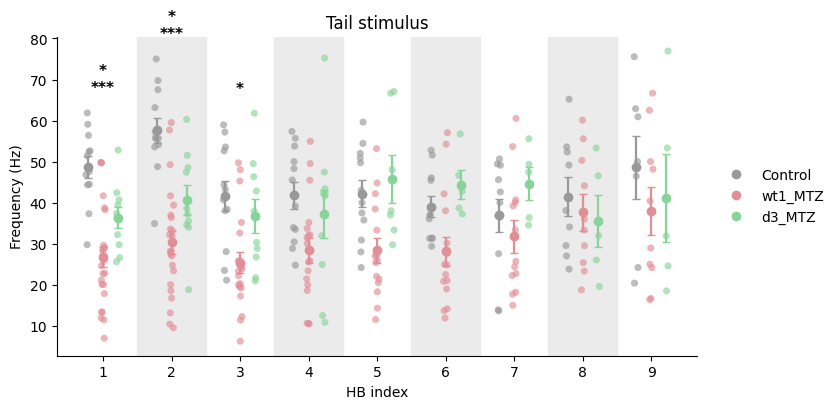

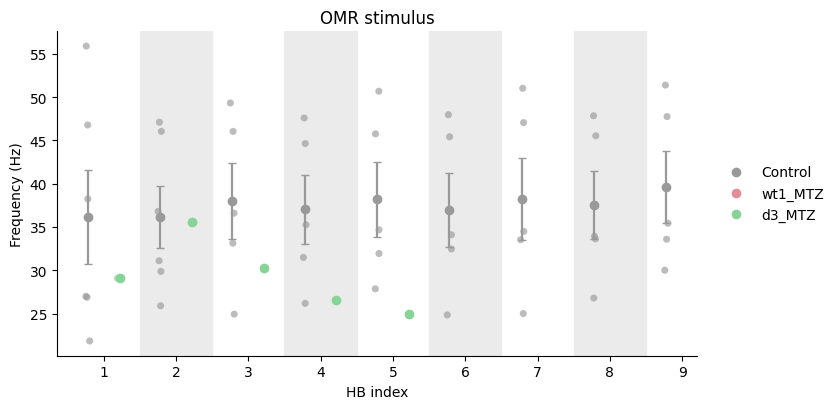

In [190]:
# 用法1
df_fish_clean = df_fish_clean[df_fish_clean["Inst_freq_Hz"] < 80]

tab_head = plot_instfreq_anova_pairs(df_fish_clean, stim="Head", y="Inst_freq_Hz", Ylabel="Frequency (Hz)")
tab_tail = plot_instfreq_anova_pairs(df_fish_clean, stim="Tail", y="Inst_freq_Hz", Ylabel="Frequency (Hz)")
tab_omr  = plot_instfreq_anova_pairs(df_fish_clean, stim="OMR",  y="Inst_freq_Hz", Ylabel="Frequency (Hz)")

# For each HB_index, we compared Control with wt1_MTZ and d3_MTZ using Welch’s t-test. P values were corrected for multiple comparisons across HB indices using Holm adjustment.

#

In [194]:
tab_head
tab_head.to_csv(os.path.join(folder, "stats_Control_vs_treat_Head.csv"), index=False)
tab_tail.to_csv(os.path.join(folder, "stats_Control_vs_treat_Tail.csv"), index=False)
tab_omr.to_csv(os.path.join(folder, "stats_Control_vs_treat_OMR.csv"), index=False)


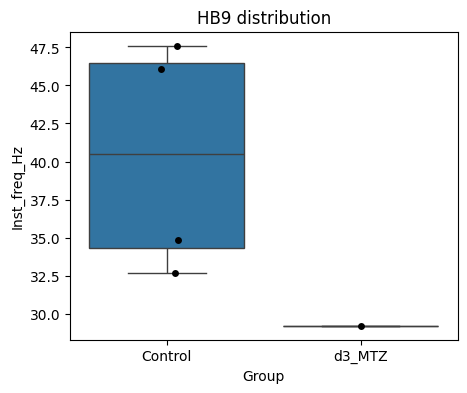

In [168]:
# 看看 Control 某个 HB（比如 HB2）是不是被 1–2 条鱼拉宽。
import seaborn as sns
import matplotlib.pyplot as plt

hb =
sub_hb = df_fish_clean[
    (df_fish_clean["Stimulus"]=="Head") &
    (df_fish_clean["HB_index"]==hb)
]

plt.figure(figsize=(5,4))
sns.boxplot(data=sub_hb, x="Group", y="Inst_freq_Hz")
sns.stripplot(data=sub_hb, x="Group", y="Inst_freq_Hz", color="black", size=5)
plt.title(f"HB{hb} distribution")
plt.show()

In [174]:
sub_hb.groupby(["HB_index","Group"])["UniqueID"].nunique()

HB_index  Group  
9         Control    4
          d3_MTZ     1
Name: UniqueID, dtype: int64

In [199]:
# p value
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, ttest_ind

groups = ["Control", "wt1_MTZ", "d3_MTZ"]
pairs = [("Control","wt1_MTZ"), ("Control","d3_MTZ"), ("wt1_MTZ","d3_MTZ")]

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    for k, idx in enumerate(order):
        adj[idx] = min((m - k) * pvals[idx], 1.0)
    # monotonicity
    adj_sorted = adj[order]
    adj_sorted = np.maximum.accumulate(adj_sorted)
    adj[order] = adj_sorted
    return adj.tolist()

def fdr_bh(pvals):
    """Benjamini-Hochberg FDR"""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(m, dtype=float)
    out[order] = q
    return out.tolist()

def hbwise_anova_posthoc(df_fish_clean, stim="Head", y="Inst_freq_Hz"):
    sub = df_fish_clean[df_fish_clean["Stimulus"] == stim].copy()
    sub = sub.dropna(subset=[y, "HB_index", "Group"])

    hbs = sorted(sub["HB_index"].unique())

    results = []
    anova_pvals = []

    # 1) 每个HB：ANOVA
    for hb in hbs:
        vals = []
        ns = []
        for g in groups:
            v = sub[(sub["Group"] == g) & (sub["HB_index"] == hb)][y].to_numpy()
            vals.append(v)
            ns.append(len(v))

        # 要求每组至少2个才做ANOVA比较稳
        if any(n < 2 for n in ns):
            anova_p = np.nan
        else:
            anova_p = f_oneway(*vals).pvalue

        anova_pvals.append(anova_p)
        results.append({"Stimulus": stim, "HB_index": hb, "ANOVA_p": anova_p})

    # 2) 对 9个HB 的 ANOVA p 做 FDR（可选但推荐）
    valid_idx = [i for i,p in enumerate(anova_pvals) if np.isfinite(p)]
    anova_q = [np.nan]*len(anova_pvals)
    if valid_idx:
        qvals = fdr_bh([anova_pvals[i] for i in valid_idx])
        for i, q in zip(valid_idx, qvals):
            anova_q[i] = q

    # 3) 每个HB：pairwise（并对该HB的三次比较做 Holm 校正）
    for i, hb in enumerate(hbs):
        row = results[i]
        row["ANOVA_q"] = anova_q[i]

        # 只有 ANOVA（或ANOVA_q）显著才做posthoc（你也可以改成永远做）
        if not np.isfinite(row["ANOVA_p"]) or row["ANOVA_p"] >= 0.05:
            for (g1,g2) in pairs:
                row[f"{g1}_vs_{g2}_p"] = np.nan
                row[f"{g1}_vs_{g2}_p_holm"] = np.nan
            continue

        pvals = []
        raw = {}
        for (g1,g2) in pairs:
            v1 = sub[(sub["Group"] == g1) & (sub["HB_index"] == hb)][y].to_numpy()
            v2 = sub[(sub["Group"] == g2) & (sub["HB_index"] == hb)][y].to_numpy()
            p = ttest_ind(v1, v2, equal_var=False).pvalue
            raw[(g1,g2)] = p
            pvals.append(p)

        adj = holm_adjust(pvals)
        for (g1,g2), p, ph in zip(pairs, pvals, adj):
            row[f"{g1}_vs_{g2}_p"] = p
            row[f"{g1}_vs_{g2}_p_holm"] = ph

    return pd.DataFrame(results)

# 用法：
res_head = hbwise_anova_posthoc(df, stim="Head",y = "Interval_s")
res_tail = hbwise_anova_posthoc(df, stim="Tail",y = "Interval_s")
res_head.to_csv(os.path.join(folder, "Duration_Head.csv"), index=False)
res_tail.to_csv(os.path.join(folder, "Duration_Tail.csv"), index=False)
res_head.head(20)

## explainaion
# p < 0.05 → 三组中至少有一组不同, 如果 ANOVA_q < 0.05 → 在多HB校正后仍显著 → 更稳健 这一步只是告诉你：“三组整体有差异”, 但不知道谁和谁不同。
#

,Stimulus,HB_index,ANOVA_p,ANOVA_q,Control_vs_wt1_MTZ_p,Control_vs_wt1_MTZ_p_holm,Control_vs_d3_MTZ_p,Control_vs_d3_MTZ_p_holm,wt1_MTZ_vs_d3_MTZ_p,wt1_MTZ_vs_d3_MTZ_p_holm
0,Head,1,0.000214,0.000321,0.005972,0.011945,1.097521e-03,3.292563e-03,0.120139,0.120139
1,Head,2,0.004719,0.005309,0.030404,0.076138,2.537933e-02,7.613799e-02,0.166574,0.166574
2,Head,3,0.000340,0.000437,0.035147,0.070295,4.643608e-04,1.393082e-03,0.204011,0.204011
3,Head,4,0.000189,0.000321,0.059754,0.119509,3.457935e-07,1.037381e-06,0.803865,0.803865
4,Head,5,0.000023,0.000068,0.057081,0.114163,2.834413e-08,8.503238e-08,0.279051,0.279051
5,Head,6,0.000107,0.000241,0.080390,0.160779,5.368234e-08,1.610470e-07,0.395756,0.395756
6,Head,7,0.000001,0.000012,0.061775,0.123551,3.476058e-11,1.042818e-10,0.692693,0.692693
7,Head,8,0.000005,0.000024,0.029718,0.059436,2.187172e-04,6.561515e-04,0.882250,0.882250
8,Head,9,0.006251,0.006251,0.794465,0.794465,5.122333e-03,1.536700e-02,0.168766,0.337533


# heatmap plot

Saved: \\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Freqmap_heatmap\260114  wt1 MTZ control_1000fps_freqmap_long_heatmap.png


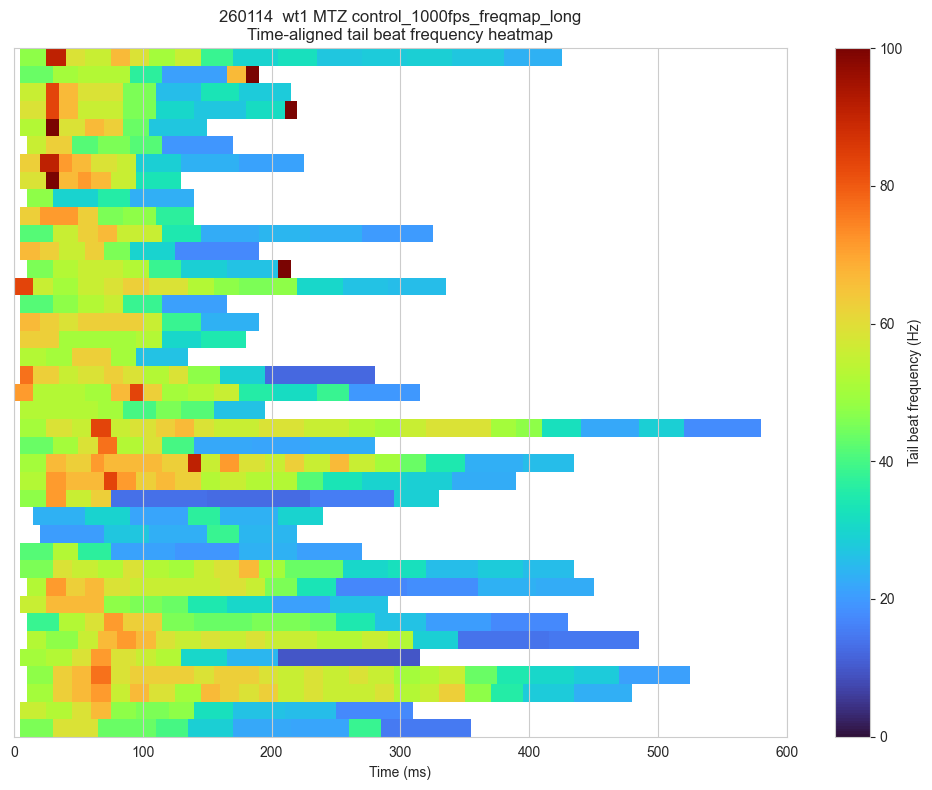

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PARAMETERS
# =========================================================
csv_path = r'U:\YuanqiHua\High speed\Final analysis\Freqmap_long\test\260114  wt1 MTZ control_1000fps_freqmap_long.csv'
save_folder = r'\\130.238.36.122\znn\YuanqiHua\High speed\Final analysis\Freqmap_heatmap'

# 统一时间轴设置
max_time_ms = 600        # X轴到多少 ms
bin_ms = 5               # 时间分箱宽度，5 ms 比较常用；也可改成 2 / 10

# 颜色范围
vmin = 0
vmax = 100               # 按你的鱼速度调，比如 80 / 100 / 120

# 排序方式
# "none"          -> 按原始顺序
# "duration"      -> 按每个 swim 最后结束时间排序
# "max_freq"      -> 按最大频率排序
# "mean_freq"     -> 按平均频率排序
sort_mode = "duration_asc"
cmap = "turbo"

show_plot = True
save_plot = True

os.makedirs(save_folder, exist_ok=True)


# =========================================================
# HELPERS
# =========================================================
def build_heatmap_matrix(df, max_time_ms=600, bin_ms=5, sort_mode="none"):
    """
    输入:
        df: freqmap_long dataframe
    输出:
        matrix: (n_swims, n_bins)
        swim_labels: 每一行对应的 swim 标签
        time_edges: 时间边界
        time_centers: 时间中心
    """

    # 给每个 swim 一个唯一标签
    # 这样不同 Larva 的同一个 Swim_ID 不会撞名
    df = df.copy()
    df["swim_key"] = (
        df["Larva_ID"].astype(str) + "|" +
        df["Genotype"].astype(str) + "|" +
        df["Swim_ID"].astype(str)
    )

    swim_keys = list(df["swim_key"].drop_duplicates())

    # 时间分箱
    n_bins = int(max_time_ms / bin_ms)
    time_edges = np.arange(0, max_time_ms + bin_ms, bin_ms)
    time_centers = time_edges[:-1] + bin_ms / 2

    # 初始化矩阵
    matrix = np.full((len(swim_keys), n_bins), np.nan, dtype=float)

    # 保存排序指标
    sort_values = []

    for row_idx, swim_key in enumerate(swim_keys):
        sub = df[df["swim_key"] == swim_key].copy()

        # 可选：按 interval 顺序排一下
        if "Interval_index" in sub.columns:
            sub = sub.sort_values("Interval_index")

        # 把每个 interval 填到对应时间段
        for _, r in sub.iterrows():
            start_ms = float(r["Start_ms"])
            end_ms = float(r["End_ms"])
            freq = float(r["Inst_freq_Hz"])

            # 跳过异常值
            if not np.isfinite(start_ms) or not np.isfinite(end_ms) or not np.isfinite(freq):
                continue
            if end_ms <= 0:
                continue
            if start_ms >= max_time_ms:
                continue

            # 截断到显示窗口
            s = max(0.0, start_ms)
            e = min(float(max_time_ms), end_ms)

            if e <= s:
                continue

            # 转成 bin index
            start_bin = int(np.floor(s / bin_ms))
            end_bin = int(np.ceil(e / bin_ms))

            start_bin = max(0, start_bin)
            end_bin = min(n_bins, end_bin)

            matrix[row_idx, start_bin:end_bin] = freq

        # 排序指标
        valid = matrix[row_idx, np.isfinite(matrix[row_idx])]
        if len(valid) == 0:
            duration_val = -np.inf
            max_freq_val = -np.inf
            mean_freq_val = -np.inf
        else:
            duration_val = np.max(sub["End_ms"].to_numpy())
            max_freq_val = np.nanmax(valid)
            mean_freq_val = np.nanmean(valid)

        if sort_mode == "duration":
            sort_values.append(duration_val)
        elif sort_mode == "max_freq":
            sort_values.append(max_freq_val)
        elif sort_mode == "mean_freq":
            sort_values.append(mean_freq_val)
        else:
            sort_values.append(row_idx)

    # 排序
    if sort_mode != "none":
        order = np.argsort(sort_values)[::-1]   # 从大到小
        matrix = matrix[order]
        swim_keys = [swim_keys[i] for i in order]

    return matrix, swim_keys, time_edges, time_centers


def make_swim_labels(swim_keys):
    labels = []
    for k in swim_keys:
        larva, genotype, swim_id = k.split("|", 2)
        labels.append(f"L{larva}_S{swim_id}")
    return labels


# =========================================================
# MAIN
# =========================================================
def main():
    df = pd.read_csv(csv_path)

    required_cols = [
        "Larva_ID", "Genotype", "Swim_ID",
        "Start_ms", "End_ms", "Inst_freq_Hz"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in csv: {missing}")

    matrix, swim_keys, time_edges, time_centers = build_heatmap_matrix(
        df,
        max_time_ms=max_time_ms,
        bin_ms=bin_ms,
        sort_mode=sort_mode
    )

    swim_labels = make_swim_labels(swim_keys)

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        extent=[0, max_time_ms, len(swim_keys), 0],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Tail beat frequency (Hz)")

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("")

    # X轴刻度
    ax.set_xticks(np.arange(0, max_time_ms + 1, 100))

    # Y轴如果太多，就不显示每一行标签
    ax.set_yticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)

    basename = os.path.splitext(os.path.basename(csv_path))[0]
    ax.set_title(f"{basename}\nTime-aligned tail beat frequency heatmap")

    plt.tight_layout()

    if save_plot:
        outpath = os.path.join(save_folder, basename + "_heatmap.png")
        plt.savefig(outpath, dpi=200, bbox_inches="tight")
        print("Saved:", outpath)

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    main()

In [ ]:
# 运动强度类 运动幅度有多大
# Max. deflection
# Longest tail trajectory
# Cumulative tail trajectory
# Max curvature


In [ ]:
# 节律类 运动快慢 / 动力节律
# Nr. half beats
# Freq. half beats

In [ ]:
# 持续时间 运动是否持续
# Movement duration
# Swimming duration

In [ ]:
# 运动对称性 是否有偏侧化（neural asymmetry）
# Turning bias R/L